In [1]:
from cooltrack.predictor import CoolTrackPredictor

oracle = CoolTrackPredictor(
    dat_filepath="../data/cooltrack_coefficients.dat", 
    age_data_path="../data/age_data"
)

planet_params = {
    'mass_Mj': 11.2, 
    'T_irr': 100.0, 
    'Met': 0.0, 
    'core': 10.0, 
    'f_sed_refractory': 4.0, 
    'f_sed_volatile': 4.0, 
    'kzz': 8.0
}

target_age = 150e6

# Tell the oracle to run 1000 Monte Carlo draws!
results = oracle.predict(target_planet=planet_params, target_age_yr=target_age, n_draws=100)

t_median = results['T_int']
t_err_minus = t_median - results.get('T_int_lower', t_median)
t_err_plus = results.get('T_int_upper', t_median) - t_median

print(f"Intrinsic Temp : {t_median:.2f} (+{t_err_plus:.2f} / -{t_err_minus:.2f}) K")

# The engine creates '_lower' (16th percentile) and '_upper' (84th percentile) keys for errors
r_median = results['Req_Rj']
r_err_minus = r_median - results['Req_Rj_lower']
r_err_plus = results['Req_Rj_upper'] - r_median

print(f"Radius         : {r_median:.3f} (+{r_err_plus:.3f} / -{r_err_minus:.3f}) R_J")

# It also does this for every photometric band in your grid!
if 'log_Keck/NIRC2.J' in results:
    j_median = results['log_Keck/NIRC2.J']
    j_err_minus = j_median - results['log_Keck/NIRC2.J_lower']
    j_err_plus = results['log_Keck/NIRC2.J_upper'] - j_median
    print(f"Keck J-Band    : {j_median:.3f} (+{j_err_plus:.3f} / -{j_err_minus:.3f}) dex")

2026-05-05 14:02:23,254 - INFO - Loaded initial condition interpolators from 4 files.


Intrinsic Temp : 749.11 (+136.68 / -181.24) K
Radius         : 1.223 (+1.365 / -0.853) R_J
Keck J-Band    : 4.109 (+0.214 / -0.304) dex


Booting up CoolTrack Oracle...


2026-05-05 14:18:39,970 - INFO - Loaded initial condition interpolators from 4 files.



Evaluating stability across 20 trials per setting...
-----------------------------------------------------------------
n_draws    | Estimated Error (dex)     | Avg Time (ms)  
-----------------------------------------------------------------
5          | 0.1814 ± 0.0481 dex       | 139.89 ms
10         | 0.1853 ± 0.0313 dex       | 221.29 ms
25         | 0.2318 ± 0.0383 dex       | 460.17 ms
50         | 0.2395 ± 0.0290 dex       | 852.72 ms
100        | 0.2536 ± 0.0210 dex       | 1714.22 ms
250        | 0.2503 ± 0.0138 dex       | 3748.79 ms
500        | 0.2489 ± 0.0089 dex       | 7521.06 ms
1000       | 0.2485 ± 0.0050 dex       | 15137.26 ms


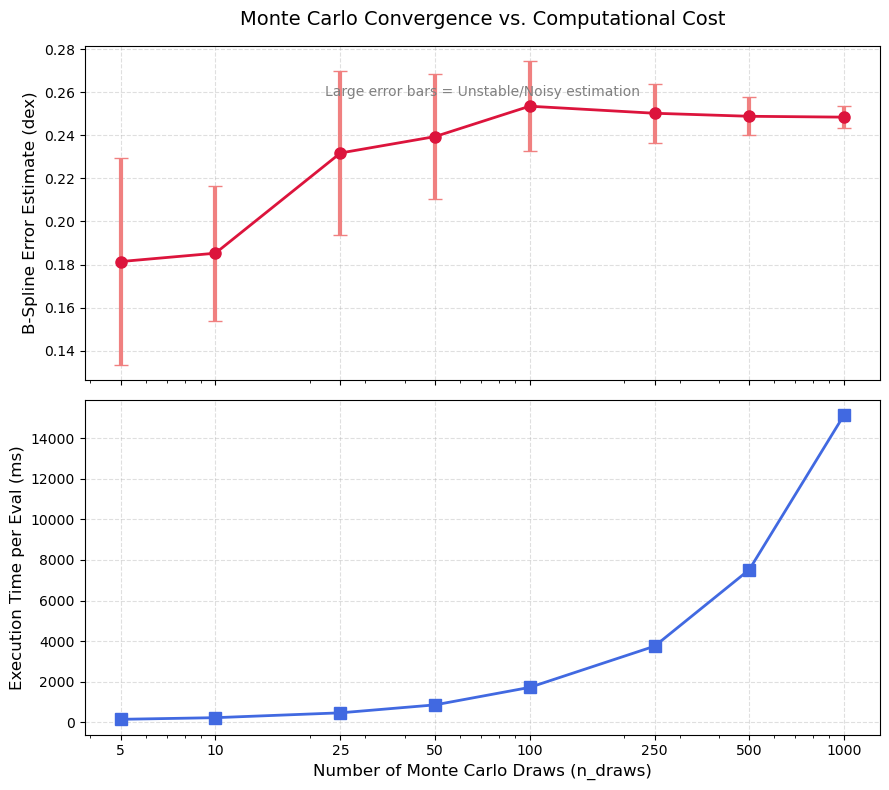

In [3]:
# --- RUN THIS ENTIRE BLOCK IN ONE JUPYTER CELL ---
%matplotlib inline

import os
import sys
import time
import numpy as np
import matplotlib.pyplot as plt

# Ensure Python can find the cooltrack modules
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from cooltrack.predictor import CoolTrackPredictor

# ==========================================
# 1. Setup the Oracle and Test Planet
# ==========================================
print("Booting up CoolTrack Oracle...")
oracle = CoolTrackPredictor(
    dat_filepath="../data/cooltrack_coefficients.dat", 
    age_data_path="../data/age_data"
)

# A standard test planet
planet_params = {
    'mass_Mj': 5.0, 
    'T_irr': 0.0, 
    'Met': 0.0, 
    'core': 10.0, 
    'f_sed_refractory': 6.0, 
    'f_sed_volatile': 6.0, 
    'kzz': 8.0
}

TARGET_AGE_YR = 150e6
OBSERVED_BAND = 'log_Keck/NIRC2.J'

# ==========================================
# 2. Run the Convergence Experiment
# ==========================================
# The different amounts of Monte Carlo draws we want to test
draw_counts = [5, 10, 25, 50, 100, 250, 500, 1000]
n_trials = 20  # Run each setting 20 times to measure how much the error fluctuates

mean_errors = []
std_of_errors = []
avg_times_ms = []

print(f"\nEvaluating stability across {n_trials} trials per setting...")
print("-" * 65)
print(f"{'n_draws':<10} | {'Estimated Error (dex)':<25} | {'Avg Time (ms)':<15}")
print("-" * 65)

for nd in draw_counts:
    trial_errors = []
    start_time = time.time()
    
    # Run the Oracle 20 times to see if the error estimate is stable
    for _ in range(n_trials):
        results = oracle.predict(planet_params, TARGET_AGE_YR, n_draws=nd)
        
        # Calculate the 1-sigma B-spline error for this run
        upper = results.get(f"{OBSERVED_BAND}_upper", 0.0)
        lower = results.get(f"{OBSERVED_BAND}_lower", 0.0)
        
        # Avoid zero division if band is missing
        if upper != 0.0 and lower != 0.0:
            trial_errors.append((upper - lower) / 2.0)
        else:
            trial_errors.append(0.0)
            
    # Calculate execution time per run
    total_time = time.time() - start_time
    dt_ms = (total_time / n_trials) * 1000
    
    # Calculate statistics
    mean_err = np.mean(trial_errors)
    std_err = np.std(trial_errors) # This is the "noise" in our error estimation
    
    mean_errors.append(mean_err)
    std_of_errors.append(std_err)
    avg_times_ms.append(dt_ms)
    
    print(f"{nd:<10} | {mean_err:.4f} ± {std_err:.4f} dex{' ':>6} | {dt_ms:.2f} ms")

# ==========================================
# 3. Plot the Results
# ==========================================
mean_errors = np.array(mean_errors)
std_of_errors = np.array(std_of_errors)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

# --- Top Panel: Error Stability ---
ax1.errorbar(draw_counts, mean_errors, yerr=std_of_errors, fmt='-o', color='crimson', 
             ecolor='lightcoral', elinewidth=3, capsize=5, lw=2, markersize=8)
ax1.set_ylabel('B-Spline Error Estimate (dex)', fontsize=12)
ax1.set_title('Monte Carlo Convergence vs. Computational Cost', fontsize=14, pad=15)
ax1.grid(True, alpha=0.4, linestyle='--')
# Annotate what the error bars mean
ax1.text(0.5, 0.85, "Large error bars = Unstable/Noisy estimation", 
         transform=ax1.transAxes, fontsize=10, color='gray', ha='center')

# --- Bottom Panel: Computational Cost ---
ax2.plot(draw_counts, avg_times_ms, '-s', color='royalblue', lw=2, markersize=8)
ax2.set_ylabel('Execution Time per Eval (ms)', fontsize=12)
ax2.set_xlabel('Number of Monte Carlo Draws (n_draws)', fontsize=12)
ax2.set_xscale('log') # Log scale is best for viewing the jump from 5 to 1000
ax2.set_xticks(draw_counts)
ax2.set_xticklabels(draw_counts)
ax2.grid(True, alpha=0.4, linestyle='--')

plt.tight_layout()
plt.show()

Booting up CoolTrack Oracle...


2026-05-05 21:42:16,867 - INFO - Loaded initial condition interpolators from 4 files.


Loaded 142 photometric bands from cooltrack.constants...

Running full grid error survey (n_draws=100)...
--- 1-Sigma B-Spline Error Matrix (dex) ---
                F070W  F090W  F115W  F140M  F150W  F182M  F200W  F210M  F250M  \
1 Mj (10 Myr)   0.524  0.360  0.308  0.240  0.397  0.219  0.256  0.258  0.240   
5 Mj (150 Myr)  0.441  0.244  0.200  0.195  0.333  0.234  0.277  0.327  0.288   
10 Mj (1 Gyr)   0.377  0.280  0.250  0.205  0.303  0.239  0.260  0.285  0.217   
15 Mj (5 Gyr)   0.317  0.268  0.226  0.189  0.330  0.236  0.234  0.305  0.267   

                F277W  ...    7_7    8_7    9_7      N   11_7  12_282  12_33  \
1 Mj (10 Myr)   0.225  ...  0.164  0.090  0.052  0.051  0.062   0.066  0.059   
5 Mj (150 Myr)  0.248  ...  0.161  0.098  0.061  0.056  0.060   0.059  0.065   
10 Mj (1 Gyr)   0.223  ...  0.146  0.101  0.058  0.059  0.061   0.052  0.044   
15 Mj (5 Gyr)   0.244  ...  0.119  0.093  0.067  0.054  0.055   0.058  0.052   

                   18     20     24  
1 Mj 

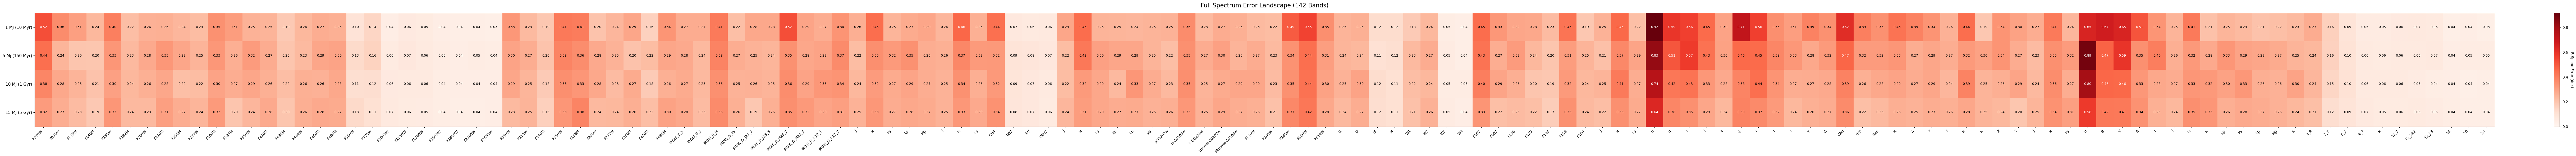

In [4]:
# --- RUN THIS ENTIRE BLOCK IN ONE JUPYTER CELL ---
%matplotlib inline

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure Python can find the cooltrack modules
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from cooltrack.predictor import CoolTrackPredictor
from cooltrack.constants import PHOTOMETRY_BANDS

# ==========================================
# 1. Setup the Oracle
# ==========================================
print("Booting up CoolTrack Oracle...")
oracle = CoolTrackPredictor(
    dat_filepath="../data/cooltrack_coefficients.dat", 
    age_data_path="../data/age_data"
)

base_params = {
    'T_irr': 0.0, 'Met': 0.0, 'core': 10.0, 'kzz': 8.0,
    'f_sed_refractory': 6.0, 'f_sed_volatile': 6.0
}

# The extreme states we want to test
test_planets = [
    {"name": "1 Mj (10 Myr)",   "mass": 1.0,  "age": 10e6},
    {"name": "5 Mj (150 Myr)",  "mass": 5.0,  "age": 150e6},
    {"name": "10 Mj (1 Gyr)",   "mass": 10.0, "age": 1e9},
    {"name": "15 Mj (5 Gyr)",   "mass": 15.0, "age": 5e9}
]

test_bands = PHOTOMETRY_BANDS
print(f"Loaded {len(test_bands)} photometric bands from cooltrack.constants...\n")

# ==========================================
# 2. Run the Massive Survey
# ==========================================
print("Running full grid error survey (n_draws=100)...")
results_data = np.zeros((len(test_planets), len(test_bands)))

for i, test in enumerate(test_planets):
    planet = base_params.copy()
    planet['mass_Mj'] = test['mass']
    
    # Run the converged Monte Carlo
    res = oracle.predict(planet, test['age'], n_draws=100)
    
    for j, band in enumerate(test_bands):
        # ---> THE FIX: Add 'log_' to the front of the band search key! <---
        upper = res.get(f"log_{band}_upper", np.nan)
        lower = res.get(f"log_{band}_lower", np.nan)
        
        if not np.isnan(upper) and not np.isnan(lower):
            error_dex = (upper - lower) / 2.0
            results_data[i, j] = error_dex
        else:
            results_data[i, j] = np.nan

# ==========================================
# 3. Display & Plot Panoramic Results
# ==========================================
# Clean up band names for the display (remove instrument prefixes to save space)
clean_band_names = [b.split('.')[-1] if '.' in b else b for b in test_bands]

# Print DataFrame
df_results = pd.DataFrame(
    results_data, 
    columns=clean_band_names, 
    index=[p['name'] for p in test_planets]
)
print("--- 1-Sigma B-Spline Error Matrix (dex) ---")
print(df_results.round(3))

# Plot a wide Heatmap
fig_width = max(10, len(test_bands) * 0.8)
fig, ax = plt.subplots(figsize=(fig_width, 6))

cax = ax.imshow(results_data, cmap='Reds', aspect='auto', vmin=0.0)

# Add colorbar
cbar = fig.colorbar(cax, pad=0.02)
cbar.set_label('B-Spline Error (dex)', rotation=270, labelpad=15)

# Format axes
ax.set_xticks(np.arange(len(test_bands)))
ax.set_yticks(np.arange(len(test_planets)))
ax.set_xticklabels(clean_band_names, fontsize=10, rotation=45, ha='right')
ax.set_yticklabels([p['name'] for p in test_planets], fontsize=11)
ax.set_title(f"Full Spectrum Error Landscape ({len(test_bands)} Bands)", fontsize=16, pad=15)

# Annotate each cell with the exact numeric error
for i in range(len(test_planets)):
    for j in range(len(test_bands)):
        val = results_data[i, j]
        if not np.isnan(val):
            # Use white text on dark red backgrounds, black on light backgrounds
            color = "white" if val > (np.nanmax(results_data) / 2) else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color, fontsize=9)

plt.tight_layout()
plt.show()

Booting up CoolTrack Oracle...


2026-05-05 22:41:42,553 - INFO - Loaded initial condition interpolators from 4 files.


Sweeping log-scaled grid gaps for Keck/NIRC2.J at 150.0 Myr...
Log Gap -0.52 to -0.40 (Linear:  0.3 to  0.4 M_J) : 24.398 dex
Log Gap -0.40 to -0.28 (Linear:  0.4 to  0.5 M_J) : 10.257 dex
Log Gap -0.28 to -0.16 (Linear:  0.5 to  0.7 M_J) : 0.582 dex
Log Gap -0.16 to -0.04 (Linear:  0.7 to  0.9 M_J) : 0.500 dex
Log Gap -0.04 to 0.08 (Linear:  0.9 to  1.2 M_J) : 0.346 dex
Log Gap 0.08 to 0.21 (Linear:  1.2 to  1.6 M_J) : 0.565 dex
Log Gap 0.21 to 0.33 (Linear:  1.6 to  2.1 M_J) : 0.639 dex
Log Gap 0.33 to 0.45 (Linear:  2.1 to  2.8 M_J) : 0.606 dex
Log Gap 0.45 to 0.57 (Linear:  2.8 to  3.7 M_J) : 0.429 dex
Log Gap 0.57 to 0.69 (Linear:  3.7 to  4.9 M_J) : 0.297 dex
Log Gap 0.69 to 0.81 (Linear:  4.9 to  6.5 M_J) : 0.229 dex
Log Gap 0.81 to 0.93 (Linear:  6.5 to  8.6 M_J) : 0.177 dex
Log Gap 0.93 to 1.05 (Linear:  8.6 to 11.3 M_J) : 0.124 dex
Log Gap 1.05 to 1.18 (Linear: 11.3 to 15.0 M_J) : 0.138 dex

      LOG-SCALED DISTANCE PENALTY RESULTS      
Average log-grid gap penalty : 2.806 

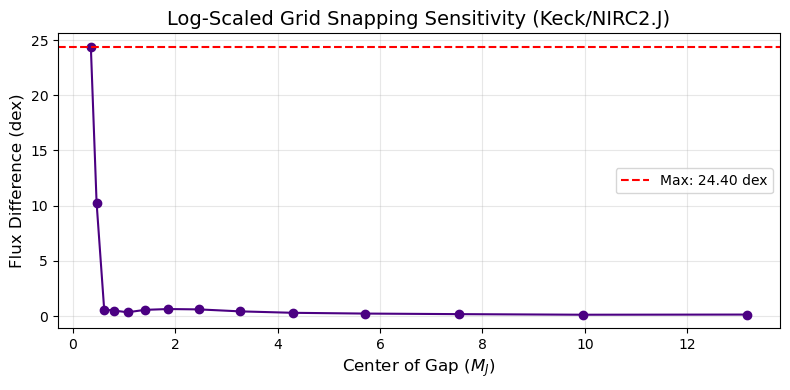

In [11]:
# --- RUN THIS ENTIRE BLOCK IN ONE JUPYTER CELL ---
%matplotlib inline

import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# Ensure Python can find the cooltrack modules
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from cooltrack.predictor import CoolTrackPredictor

# ==========================================
# 1. Setup the Oracle
# ==========================================
print("Booting up CoolTrack Oracle...")
oracle = CoolTrackPredictor(
    dat_filepath="../data/cooltrack_coefficients.dat", 
    age_data_path="../data/age_data"
)

TARGET_AGE_YR = 150e6
OBSERVED_BAND = 'Keck/NIRC2.J'  

base_params = {
    'T_irr': 0.0, 'Met': 0.0, 'core': 10.0, 'kzz': 8.0,
    'f_sed_refractory': 6.0, 'f_sed_volatile': 6.0
}

# ==========================================
# 2. Run the Log-Scaled Calibration Sweep
# ==========================================
print(f"Sweeping log-scaled grid gaps for {OBSERVED_BAND} at {TARGET_AGE_YR/1e6} Myr...")

# Create 15 evenly spaced points in LOG10 space
# This perfectly matches the "stride length" of your MCMC walkers
num_points = 15
log_masses = np.linspace(np.log10(0.3), np.log10(15.0), num_points)

flux_differences = []
gap_centers_linear = [] # For plotting

for i in range(len(log_masses) - 1):
    # 1. Evaluate the lower edge of the log-gap
    mass_lower = 10**log_masses[i]
    p_lower = base_params.copy()
    p_lower['mass_Mj'] = mass_lower
    res_lower = oracle.predict(p_lower, TARGET_AGE_YR, n_draws=0)
    flux_lower = res_lower.get(f"log_{OBSERVED_BAND}", np.nan)
    
    # 2. Evaluate the upper edge of the log-gap
    mass_upper = 10**log_masses[i+1]
    p_upper = base_params.copy()
    p_upper['mass_Mj'] = mass_upper
    res_upper = oracle.predict(p_upper, TARGET_AGE_YR, n_draws=0)
    flux_upper = res_upper.get(f"log_{OBSERVED_BAND}", np.nan)
    
    # 3. Calculate the absolute difference
    if not np.isnan(flux_lower) and not np.isnan(flux_upper):
        delta = abs(flux_upper - flux_lower)
        flux_differences.append(delta)
        gap_centers_linear.append((mass_lower + mass_upper) / 2.0)
        print(f"Log Gap {log_masses[i]:.2f} to {log_masses[i+1]:.2f} (Linear: {mass_lower:>4.1f} to {mass_upper:>4.1f} M_J) : {delta:.3f} dex")
    else:
        flux_differences.append(np.nan)
        gap_centers_linear.append((mass_lower + mass_upper) / 2.0)
        print(f"Log Gap {log_masses[i]:.2f} to {log_masses[i+1]:.2f} : NaN (Out of bounds)")

# ==========================================
# 3. Results & Recommendation
# ==========================================
flux_differences = np.array(flux_differences)
valid_deltas = flux_differences[~np.isnan(flux_differences)]

if len(valid_deltas) > 0:
    max_penalty = np.max(valid_deltas)
    mean_penalty = np.mean(valid_deltas)
    
    print("\n" + "="*55)
    print("      LOG-SCALED DISTANCE PENALTY RESULTS      ")
    print("="*55)
    print(f"Average log-grid gap penalty : {mean_penalty:.3f} dex")
    print(f"Maximum log-grid gap penalty : {max_penalty:.3f} dex")
    print("-" * 55)
    print(f"RECOMMENDATION: Set DISTANCE_PENALTY_SCALER = {max_penalty:.2f}")
    print("="*55)
    
    # Plotting against the linear mass center for readability
    plt.figure(figsize=(8, 4))
    plt.plot(gap_centers_linear, flux_differences, marker='o', linestyle='-', color='indigo')
    plt.axhline(max_penalty, color='red', linestyle='--', label=f'Max: {max_penalty:.2f} dex')
    plt.title(f'Log-Scaled Grid Snapping Sensitivity ({OBSERVED_BAND})', fontsize=14)
    plt.xlabel('Center of Gap ($M_J$)', fontsize=12)
    plt.ylabel('Flux Difference (dex)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Could not evaluate the grid gaps. Check your parameters.")

Booting up CoolTrack Oracle...


2026-05-05 23:01:46,920 - INFO - Loaded initial condition interpolators from 4 files.



[Phase 1] Profiling Local Grid Resolution Penalties...
--> Grid Profiler Complete (0.4s): Local gap errors range from 0.098 to 0.546 dex.

[Phase 2] Profiling B-Spline Interpolation Error...
--> B-Spline Profiler Complete (7.5s): Error ranges from 0.229 to 0.277 dex.

[Phase 3] Launching Autonomous MCMC...


100%|██████████| 1000/1000 [01:03<00:00, 15.68it/s]



         FINAL RETRIEVAL RESULTS        
   Mass ($M_J$): 3.26 (+1.04 / -0.82)


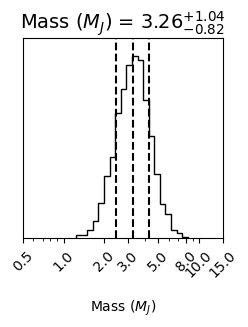

In [13]:
# --- RUN THIS ENTIRE BLOCK IN ONE JUPYTER CELL ---
%matplotlib inline

import os
import sys
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import corner
import emcee
from multiprocessing import Pool, cpu_count

# ==========================================
# 0. SYSTEM CRITICAL OVERRIDES
# ==========================================
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from cooltrack.predictor import CoolTrackPredictor

# ==========================================
# 1. SETUP: ORACLE & OBSERVATIONS
# ==========================================
print("Booting up CoolTrack Oracle...")
oracle = CoolTrackPredictor(
    dat_filepath="../data/cooltrack_coefficients.dat", 
    age_data_path="../data/age_data"
)

TARGET_AGE_YR = 150e6
OBSERVED_BAND = 'Keck/NIRC2.J'  
OBSERVED_FLUX = 3.0  
FLUX_ERROR = 0.05               

MIN_MASS = 0.5
MAX_MASS = 15.0

FIXED_PARAMS = {
    'T_irr': 0.0, 'Met': 0.0, 'core': 10.0, 'kzz': 8.0,
    'f_sed_refractory': 6.0, 'f_sed_volatile': 6.0
}

# ==========================================
# 2. PHASE 1: DYNAMIC GRID RESOLUTION PROFILER
# ==========================================
print(f"\n[Phase 1] Profiling Local Grid Resolution Penalties...")
t0 = time.time()

num_calib_points = 15
log_masses_calib = np.linspace(np.log10(MIN_MASS), np.log10(MAX_MASS), num_calib_points)

gap_centers = []
gap_errors = []

for i in range(len(log_masses_calib) - 1):
    mass_lower = 10**log_masses_calib[i]
    mass_upper = 10**log_masses_calib[i+1]
    
    p_lower = FIXED_PARAMS.copy()
    p_lower['mass_Mj'] = mass_lower
    res_lower = oracle.predict(p_lower, TARGET_AGE_YR, n_draws=0)
    flux_lower = res_lower.get(f"log_{OBSERVED_BAND}", np.nan)
    
    p_upper = FIXED_PARAMS.copy()
    p_upper['mass_Mj'] = mass_upper
    res_upper = oracle.predict(p_upper, TARGET_AGE_YR, n_draws=0)
    flux_upper = res_upper.get(f"log_{OBSERVED_BAND}", np.nan)
    
    if not np.isnan(flux_lower) and not np.isnan(flux_upper):
        delta = abs(flux_upper - flux_lower)
        # Cap catastrophic physical cliffs to prevent interpolation blowouts
        if delta > 2.0: delta = 2.0 
        
        # Save the linear center of this gap and its specific error
        center_mass = 10**((log_masses_calib[i] + log_masses_calib[i+1]) / 2.0)
        gap_centers.append(center_mass)
        gap_errors.append(delta)

gap_centers = np.array(gap_centers)
gap_errors = np.array(gap_errors)

print(f"--> Grid Profiler Complete ({time.time()-t0:.1f}s): Local gap errors range from {gap_errors.min():.3f} to {gap_errors.max():.3f} dex.")

# ==========================================
# 3. PHASE 2: B-SPLINE ERROR PROFILER
# ==========================================
print(f"\n[Phase 2] Profiling B-Spline Interpolation Error...")
t1 = time.time()

profile_masses = np.linspace(MIN_MASS, MAX_MASS, 6)
profile_errors = []

for pm in profile_masses:
    planet = FIXED_PARAMS.copy()
    planet['mass_Mj'] = pm
    
    res = oracle.predict(planet, TARGET_AGE_YR, n_draws=100)
    
    upper = res.get(f"log_{OBSERVED_BAND}_upper", np.nan)
    lower = res.get(f"log_{OBSERVED_BAND}_lower", np.nan)
    
    if not np.isnan(upper) and not np.isnan(lower):
        profile_errors.append((upper - lower) / 2.0)
    else:
        profile_errors.append(0.30) 

profile_errors = np.array(profile_errors)
print(f"--> B-Spline Profiler Complete ({time.time()-t1:.1f}s): Error ranges from {profile_errors.min():.3f} to {profile_errors.max():.3f} dex.")

# ==========================================
# 4. PHASE 3: DOUBLE-HETEROSCEDASTIC MATH
# ==========================================
def log_prior(theta):
    log_mass = theta[0]
    if (np.log10(MIN_MASS) <= log_mass <= np.log10(MAX_MASS)):
        return 0.0  
    return -np.inf  

def log_likelihood(theta):
    log_mass = theta[0]
    linear_mass = 10**log_mass
    
    planet = FIXED_PARAMS.copy()
    planet['mass_Mj'] = linear_mass  
    
    try:
        results = oracle.predict(planet, TARGET_AGE_YR, n_draws=0)
        
        model_flux = results.get(f"log_{OBSERVED_BAND}", np.nan)
        if np.isnan(model_flux):
            return -np.inf
            
        # Error 1: Observation
        obs_var = FLUX_ERROR**2
        
        # Error 2: HETEROSCEDASTIC B-Spline Error
        dynamic_bspline_err = np.interp(linear_mass, profile_masses, profile_errors)
        bspline_var = dynamic_bspline_err**2
        
        # Error 3: LOCALIZED TRIANGULAR Grid Penalty
        # First, find the maximum possible error for the specific gap the walker is currently in
        local_max_gap_error = np.interp(linear_mass, gap_centers, gap_errors)
        
        # Then scale it by how close the walker is to the safe node
        fractional_distance = min(results['snap_distance'] / 0.5, 1.0)
        grid_err = local_max_gap_error * fractional_distance
        grid_var = grid_err**2
        
        # Combine all variances dynamically
        total_variance = obs_var + bspline_var + grid_var
        residual = model_flux - OBSERVED_FLUX
        
        return -0.5 * ((residual**2 / total_variance) + np.log(2 * np.pi * total_variance))
        
    except Exception:
        return -np.inf

def log_probability(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta)

# ==========================================
# 5. PHASE 4: RUN PARALLEL MCMC
# ==========================================
print(f"\n[Phase 3] Launching Autonomous MCMC...")
num_cores = max(1, cpu_count() - 1) 

ndim = 1         
nwalkers = 16    
nsteps = 1000    

initial_guess = np.array([np.log10(5.0)]) 
pos = initial_guess + 1e-4 * np.random.randn(nwalkers, ndim)

with Pool(num_cores) as pool:
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, pool=pool)
    sampler.run_mcmc(pos, nsteps, progress=True)

# ==========================================
# 6. POST-PROCESSING & PLOTTING
# ==========================================
burnin = int(0.2 * nsteps)
log_samples = sampler.get_chain(discard=burnin, flat=True)
linear_samples = 10**log_samples
labels = ["Mass ($M_J$)"]

print("\n" + "="*40)
print("         FINAL RETRIEVAL RESULTS        ")
print("="*40)
mcmc = np.percentile(linear_samples[:, 0], [16, 50, 84])
q = np.diff(mcmc)
print(f"{labels[0]:>15}: {mcmc[1]:.2f} (+{q[1]:.2f} / -{q[0]:.2f})")
print("="*40)

# Generate log-scaled Corner Plot
fig = corner.corner(
    linear_samples, 
    labels=labels, 
    axes_scale="log",
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True, 
    title_kwargs={"fontsize": 14}
)

ax = fig.axes[0]
formatter = ScalarFormatter()
formatter.set_scientific(False)
ax.xaxis.set_major_formatter(formatter)
ax.set_xticks([0.5, 1, 2, 3, 5, 8, 10, 15])

plt.show()

<>:69: SyntaxWarning: invalid escape sequence '\m'
<>:69: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_53471/2286634035.py:69: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel('Log Flux ($W/m^2/\mu m$)', fontsize=12)


Booting up CoolTrack Oracle...


2026-05-05 13:11:32,279 - INFO - Loaded initial condition interpolators from 4 files.


Evaluating evolutionary track...


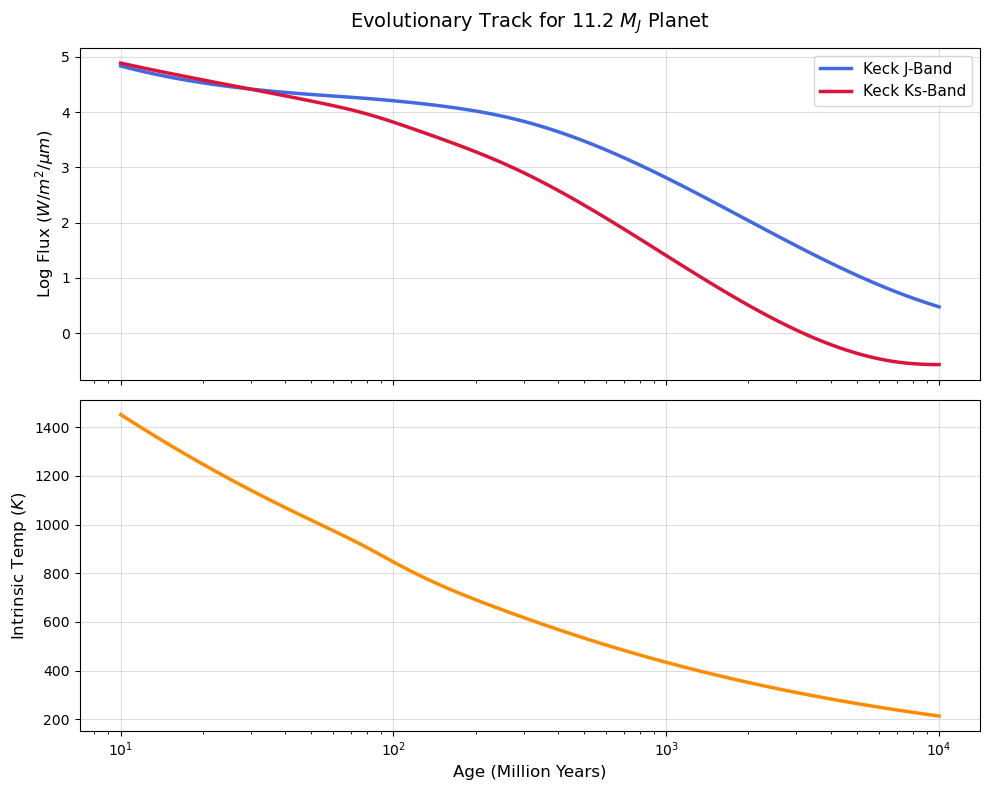

In [ ]:
# --- RUN THIS ENTIRE BLOCK IN ONE JUPYTER CELL ---
%matplotlib inline

import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# Ensure Python can find the cooltrack modules
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from cooltrack.predictor import CoolTrackPredictor

# ==========================================
# 1. Setup the Oracle
# ==========================================
DAT_FILEPATH = "../data/cooltrack_coefficients.dat"
AGE_DATA_PATH = "../data/age_data"

print("Booting up CoolTrack Oracle...")
oracle = CoolTrackPredictor(dat_filepath=DAT_FILEPATH, age_data_path=AGE_DATA_PATH)

# ==========================================
# 2. Define the Target Planet
# ==========================================
planet_params = {
    'mass_Mj': 11.2, 
    'T_irr': 100.0, 
    'Met': 0.0, 
    'core': 10.0, 
    'f_sed_refractory': 6.0, 
    'f_sed_volatile': 6.0, 
    'kzz': 8.0
}

# ==========================================
# 3. Generate Data Across Time
# ==========================================
# Create an array of 100 ages spaced logarithmically from 10 Myr (10^7) to 10 Gyr (10^10)
ages_yr = np.logspace(7, 10, 100)

j_band = []
k_band = []
t_int = []

print("Evaluating evolutionary track...")
for age in ages_yr:
    # Get the properties at each specific age step
    results = oracle.predict(target_planet=planet_params, target_age_yr=age)
    
    # Extract the metrics we want to plot (using .get() safely handles missing bands)
    j_band.append(results.get('log_Keck/NIRC2.J', np.nan))
    k_band.append(results.get('log_Keck/NIRC2.Ks', np.nan))
    t_int.append(results.get('T_int', np.nan))

# Convert to numpy arrays for easier plotting
j_band = np.array(j_band)
k_band = np.array(k_band)
t_int = np.array(t_int)

# ==========================================
# 4. Plot the Results
# ==========================================
# Create a 2-panel plot (Photometry on top, Temperature on bottom)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# --- Top Panel: Photometry ---
ax1.plot(ages_yr / 1e6, j_band, label='Keck J-Band', color='royalblue', lw=2.5)
ax1.plot(ages_yr / 1e6, k_band, label='Keck Ks-Band', color='crimson', lw=2.5)
ax1.set_ylabel('Log Flux ($W/m^2/\mu m$)', fontsize=12)
ax1.set_title(f'Evolutionary Track for {planet_params["mass_Mj"]} $M_J$ Planet', fontsize=14, pad=15)
ax1.legend(loc='best', fontsize=11)
ax1.grid(True, alpha=0.4)

# --- Bottom Panel: Intrinsic Temperature ---
ax2.plot(ages_yr / 1e6, t_int, color='darkorange', lw=2.5)
ax2.set_xlabel('Age (Million Years)', fontsize=12)
ax2.set_ylabel('Intrinsic Temp ($K$)', fontsize=12)
ax2.set_xscale('log') # Log scale is standard for cooling tracks
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

Booting up CoolTrack Oracle...


2026-05-05 23:08:19,945 - INFO - Loaded initial condition interpolators from 4 files.


Evaluating 6 evolutionary tracks...


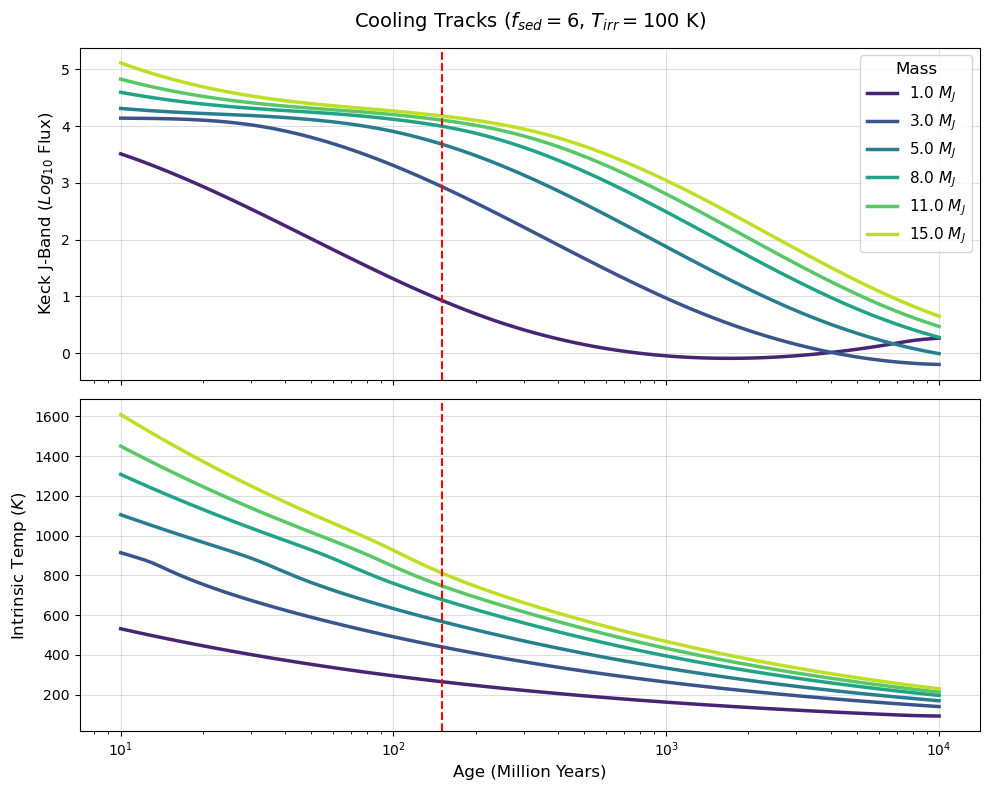

In [14]:
# --- RUN THIS ENTIRE BLOCK IN ONE JUPYTER CELL ---
%matplotlib inline

import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# Ensure Python can find the cooltrack modules
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from cooltrack.predictor import CoolTrackPredictor

# ==========================================
# 1. Setup the Oracle
# ==========================================
DAT_FILEPATH = "../data/cooltrack_coefficients.dat"
AGE_DATA_PATH = "../data/age_data"

print("Booting up CoolTrack Oracle...")
oracle = CoolTrackPredictor(dat_filepath=DAT_FILEPATH, age_data_path=AGE_DATA_PATH)

# ==========================================
# 2. Define the Target Grid
# ==========================================
# List of masses you want to overplot
masses_to_plot = [1.0, 3.0, 5.0, 8.0, 11.0, 15.0]

# Fixed parameters for all planets
base_params = {
    'T_irr': 100.0, 
    'Met': 0.0, 
    'core': 10.0, 
    'f_sed_refractory': 6.0, 
    'f_sed_volatile': 6.0, 
    'kzz': 8.0
}

# Create an array of 100 ages spaced logarithmically from 10 Myr to 10 Gyr
ages_yr = np.logspace(7, 10, 100)

# ==========================================
# 3. Evaluate & Plot the Results
# ==========================================
# Create a 2-panel plot (Photometry on top, Temperature on bottom)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Generate a nice color gradient based on the number of masses we are plotting
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(masses_to_plot)))

print(f"Evaluating {len(masses_to_plot)} evolutionary tracks...")

for i, target_mass in enumerate(masses_to_plot):
    # Update the mass for this iteration
    planet_params = base_params.copy()
    planet_params['mass_Mj'] = target_mass
    
    j_band = []
    t_int = []
    
    # Evaluate the track across all ages
    for age in ages_yr:
        results = oracle.predict(target_planet=planet_params, target_age_yr=age)
        j_band.append(results.get('log_Keck/NIRC2.J', np.nan))
        t_int.append(results.get('T_int', np.nan))
        
    # Plot this mass on the top panel (Photometry)
    ax1.plot(ages_yr / 1e6, j_band, label=f"{target_mass} $M_J$", color=colors[i], lw=2.5)
    
    # Plot this mass on the bottom panel (Temperature)
    ax2.plot(ages_yr / 1e6, t_int, color=colors[i], lw=2.5)

# --- Format Top Panel (Photometry) ---
ax1.set_ylabel('Keck J-Band ($Log_{10}$ Flux)', fontsize=12)
ax1.set_title(f'Cooling Tracks ($f_{{sed}}=6$, $T_{{irr}}=100$ K)', fontsize=14, pad=15)
ax1.legend(loc='upper right', fontsize=11, title="Mass", title_fontsize=12)
ax1.grid(True, alpha=0.4)

# Add vertical line
ax1.axvline(x=150, color='red', linestyle='--', label='150 Myr')

# --- Format Bottom Panel (Temperature) ---
ax2.set_xlabel('Age (Million Years)', fontsize=12)
ax2.set_ylabel('Intrinsic Temp ($K$)', fontsize=12)
ax2.set_xscale('log') # Log scale is standard for cooling tracks
ax2.grid(True, alpha=0.4)

ax2.axvline(x=150, color='red', linestyle='--', label='150 Myr')


plt.tight_layout()
plt.show()

Booting up CoolTrack Oracle...


2026-05-05 13:36:21,815 - INFO - Loaded initial condition interpolators from 4 files.


Evaluating 6 evolutionary tracks...


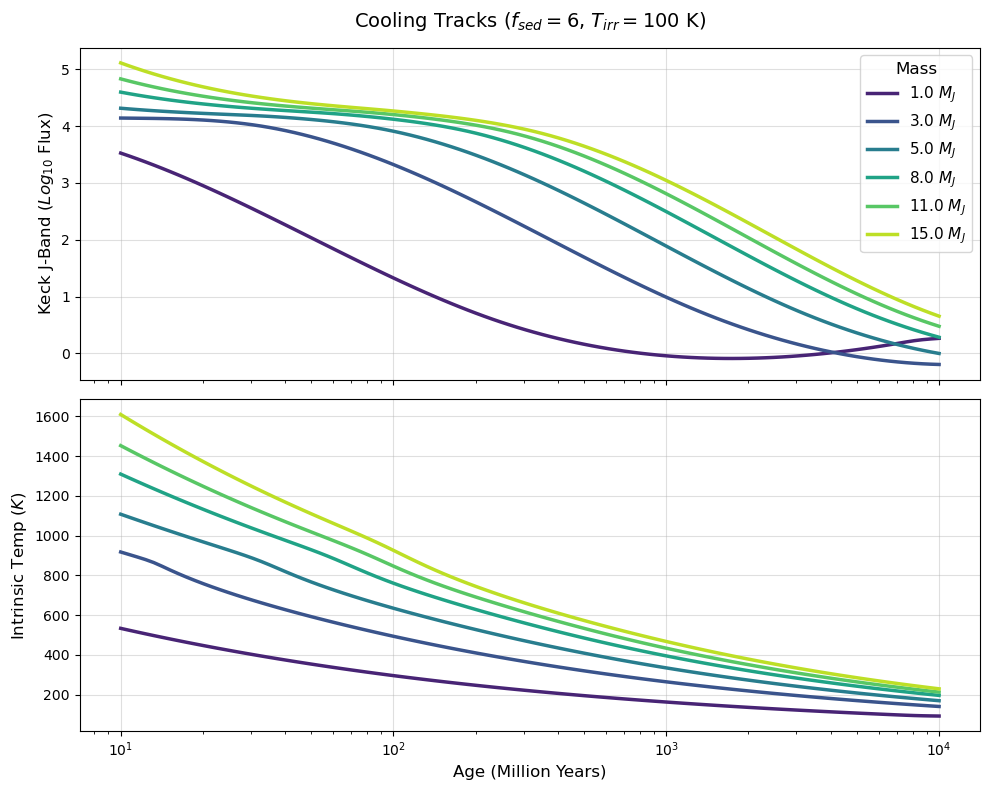

In [ ]:
# --- RUN THIS ENTIRE BLOCK IN ONE JUPYTER CELL ---
%matplotlib inline

import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# Ensure Python can find the cooltrack modules
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from cooltrack.predictor import CoolTrackPredictor

# ==========================================
# 1. Setup the Oracle
# ==========================================
DAT_FILEPATH = "../data/cooltrack_coefficients.dat"
AGE_DATA_PATH = "../data/age_data"

print("Booting up CoolTrack Oracle...")
oracle = CoolTrackPredictor(dat_filepath=DAT_FILEPATH, age_data_path=AGE_DATA_PATH)

# ==========================================
# 2. Define the Target Grid
# ==========================================
# List of masses you want to overplot
masses_to_plot = [1.0, 3.0, 5.0, 8.0, 11.0, 15.0]

# Fixed parameters for all planets
base_params = {
    'T_irr': 100.0, 
    'Met': 0.0, 
    'core': 10.0, 
    'f_sed_refractory': 6.0, 
    'f_sed_volatile': 6.0, 
    'kzz': 8.0
}

# Create an array of 100 ages spaced logarithmically from 10 Myr to 10 Gyr
ages_yr = np.logspace(7, 10, 100)

# ==========================================
# 3. Evaluate & Plot the Results
# ==========================================
# Create a 2-panel plot (Photometry on top, Temperature on bottom)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Generate a nice color gradient based on the number of masses we are plotting
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(masses_to_plot)))

print(f"Evaluating {len(masses_to_plot)} evolutionary tracks...")

for i, target_mass in enumerate(masses_to_plot):
    # Update the mass for this iteration
    planet_params = base_params.copy()
    planet_params['mass_Mj'] = target_mass
    
    j_band = []
    t_int = []
    
    # Evaluate the track across all ages
    for age in ages_yr:
        results = oracle.predict(target_planet=planet_params, target_age_yr=age)
        j_band.append(results.get('log_Keck/NIRC2.J', np.nan))
        t_int.append(results.get('T_int', np.nan))
        
    # Plot this mass on the top panel (Photometry)
    ax1.plot(ages_yr / 1e6, j_band, label=f"{target_mass} $M_J$", color=colors[i], lw=2.5)
    
    # Plot this mass on the bottom panel (Temperature)
    ax2.plot(ages_yr / 1e6, t_int, color=colors[i], lw=2.5)

# --- Format Top Panel (Photometry) ---
ax1.set_ylabel('Keck J-Band ($Log_{10}$ Flux)', fontsize=12)
ax1.set_title(f'Cooling Tracks ($f_{{sed}}=6$, $T_{{irr}}=100$ K)', fontsize=14, pad=15)
ax1.legend(loc='upper right', fontsize=11, title="Mass", title_fontsize=12)
ax1.grid(True, alpha=0.4)

# --- Format Bottom Panel (Temperature) ---
ax2.set_xlabel('Age (Million Years)', fontsize=12)
ax2.set_ylabel('Intrinsic Temp ($K$)', fontsize=12)
ax2.set_xscale('log') # Log scale is standard for cooling tracks
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()